In [39]:
import pandas as pd
import wandb
from tqdm import tqdm

from utils_modelo_reviews.preprocesamiento import read_reviews, clean_text_lemma
from fastopic import FASTopic
from topmost import Preprocess
from nltk.corpus import stopwords
import spacy
import re
from nltk.tokenize import RegexpTokenizer
from sentence_transformers import SentenceTransformer
import nltk
import numpy as np
import torch
nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng') 


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\imzli\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\imzli\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\imzli\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\imzli\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [40]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [41]:
df = read_reviews()

In [42]:
df.head(100)

,appid,is_positive,weight,text,language
1,747660,True,0.500000,nothing,en
3,747660,True,0.500000,"so, i completed the game and got all the achievements 100%, even though i'm a fan of fnaf, i didn't think i'd complete it in 3 days.",en
4,747660,True,0.500000,"its very good and worth the 40 bucks in my opinion. warehouse is hard, but beatable, and the maze in mazercise is like impossible. had to watch vid. oerall i love this",en
8,747660,True,0.500000,i like that its fun and has a lot of gameplay and content i dont like that if you dont have enough video card memory it crashes when you open certain cams and is laggy,en
10,747660,True,0.500000,holds a special place in my heart,en
...,...,...,...,...,...
143,747660,True,0.500000,fun and scary,en
146,747660,False,0.527076,"jst not good dont buy/gen, just watch someone play it that has a good computer, like markiplier, its infinitely more enjoyable",en
147,747660,True,0.500000,"great game! i have 30 hours of game play on it without regret. definitely a staple for any fnaf fan. but, i will say the game runs about 20 frames per second on steam deck and has a lot of annoying glitches like the time i was in bonnie bowl and chica was talking though the floor and killed me even though she was shattered and couldnt talk. the other issue was the fact that auto saving does not exist. either than that, the game is story rich, great graphics, and overall, very fun!",en
148,747660,True,0.500000,the best game ever super fun and very worth it!!!,en


In [43]:
tqdm.pandas(desc="Limpiando texto")

In [44]:
# python -m spacy download en_core_web_sm si no se encuentra el modelo
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "senter", "morphologizer"])

def fast_noun_extractor(texts):
    cleaned = []
    
    for doc in tqdm(nlp.pipe(texts, n_process=4, batch_size=2000), total=len(texts)):
        tokens = [
            t.lemma_.lower() 
            for t in doc 
            if t.pos_ in ("NOUN") and t.is_alpha
        ]
        cleaned.append(" ".join(tokens))
    return cleaned

df["text_clean"] = fast_noun_extractor(df["text"].astype(str).tolist())
df = df[df["text_clean"].str.split().str.len() >= 5].copy()

100%|██████████| 205883/205883 [07:15<00:00, 472.29it/s] 


In [45]:
preprocess = Preprocess(vocab_size=2000, min_doc_count=750, max_doc_freq=0.3)
model = FASTopic(num_topics = 7, verbose= True, preprocess=preprocess,device="cuda", low_memory=True, low_memory_batch_size=50000,DT_alpha = 4,TW_alpha = 4)

2026-04-07 23:51:43,876 - FASTopic - use device: cuda


In [46]:
def remove_hearts(text):
    text = re.sub(r'(hearts){2,}', '', text)
    text = re.sub('heartsheart', '', text)
    text = re.sub('heart', '', text)
    return text
df["text_clean"] = df["text_clean"].progress_apply(remove_hearts)

Limpiando texto: 100%|██████████| 115168/115168 [00:00<00:00, 165162.22it/s]


In [47]:
texts = df["text"].astype(str).tolist()
model_st = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model_st.encode(texts, show_progress_bar=True)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1082.12it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 3599/3599 [01:16<00:00, 46.76it/s] 


In [48]:
topic_top_words, doc_topic_dist = model.fit_transform(df["text_clean"].to_list(), preset_doc_embeddings = embeddings)

2026-04-07 23:53:17,197 - FASTopic - Using low memory mode.
2026-04-07 23:53:17,198 - FASTopic - First fit the model.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1261.44it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
parsing texts: 100%|██████████| 115168/115168 [00:03<00:00, 36378.52it/s]
c:\Users\imzli\Documents\Proyecto de Datos\c2526-R4\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'

2026-04-07 23:53:27,044 - TopMost - Real vocab size: 578
2026-04-07 23:53:27,047 - TopMost - Real training size: 115168 	 avg length: 16.273
Tr

Topic 0: boss weapon card enemy battle run attack fight upgrade skill damage deck gun unit build
Topic 1: story player character gameplay experience world mechanic combat puzzle design art style action sense progression
Topic 2: building simulator city management cat sim car simulation space resource control animal physics food water
Topic 3: time thing lot hour fun way bit level people point issue bug day friend review
Topic 4: scene ending horror dialogue girl novel voice choice plot room narrative adult route writing chapter
Topic 5: series sequel fan love man music remake star vibe video franchise masterpiece movie song age
Topic 6: steam developer gamer money update devs demo server review year product quality store asset release


In [59]:
df["Topic_ID"] = np.argmax(doc_topic_dist, axis=1)

topic_tags = {
    0: "Strategy / Card / Combat",
    1: "Narrative / Gameplay / Story",
    2: "Simulation / Management / Building",
    3: "Game Design / Immersion / Reviews",
    4: "Horror / Narrative / Story",
    5: "Franchise / Media / Fan",
    6: "Steam / Technical / Updates",
}


df["Topic_Name"] = df["Topic_ID"].map(topic_tags)

print(df["Topic_Name"].value_counts())

Topic_Name
Steam / Technical / Updates           24116
Strategy / Card / Combat              23591
Horror / Narrative / Story            22203
Simulation / Management / Building    15676
Franchise / Media / Fan               14114
Narrative / Gameplay / Story           7871
Game Design / Immersion / Reviews      7597
Name: count, dtype: int64


In [60]:
pd.set_option('display.max_colwidth', 500)
df

,Unnamed: 0,appid,is_positive,weight,text,language,text_clean,Topic_ID,Topic_Name
0,3,747660,True,0.500000,"so, i completed the game and got all the achievements 100%, even though i'm a fan of fnaf, i didn't think i'd complete it in 3 days.",en,game achievement fan fnaf day,3,Game Design / Immersion / Reviews
1,4,747660,True,0.500000,"its very good and worth the 40 bucks in my opinion. warehouse is hard, but beatable, and the maze in mazercise is like impossible. had to watch vid. oerall i love this",en,buck opinion warehouse maze mazercise oerall,2,Simulation / Management / Building
2,8,747660,True,0.500000,i like that its fun and has a lot of gameplay and content i dont like that if you dont have enough video card memory it crashes when you open certain cams and is laggy,en,fun lot gameplay content video card memory cam,6,Steam / Technical / Updates
3,22,747660,True,0.500000,"its very lovable game with very wasted potential. if steelwool would not rush it and work on it for year or two it would be banger. but since they did we got 20% of the content this game supposed to have and very unoptimized buggy mess. also if u look for a scary horror, this game is not for you. maybe ruin is scary a little bit. animatronics are the best this franchise ever had, all of them are very lovable with so much unique personality. roxanne wolf. amazing graphics, game looks absolute...",en,game potential steelwool year banger content game mess horror game ruin bit animatronic franchise personality graphic game atmosphere game ruin animatronic fan fnaf world model animatronic game setting time bit map feature map quality price hint detail tutorial level game time loop detail place content mod game antagonist screen time game review game love flaw exception time sequel game cassie story game time,6,Steam / Technical / Updates
4,24,747660,False,0.538462,absolutely atrocious port. how many years has it been? and this game is still riddled with bugs and glitches. i'd much rather play switch version than this. such a shame that this is the quality we get now.,en,port year game bug glitch switch version shame quality,6,Steam / Technical / Updates
...,...,...,...,...,...,...,...,...,...
115163,261260,1848440,True,0.525862,"very good game, pretty difficult at some points. likeable characters, nice art style and superb voice acting. worth every penny!",en,game point character art style superb voice penny,5,Franchise / Media / Fan
115164,261263,2198070,False,0.500000,"i really like this concept and this is theoretically really fun, but in practice the abundance of hard-to-play, not-very-beneficial cards (i.e. water treatment plants and memorial parks) and lack of useful ones (i.e. roads) makes it challenging in a distinctly un-fun way.",en,concept practice abundance play card water treatment plant park lack one road way,2,Simulation / Management / Building
115165,261265,408410,True,0.500000,i've played through this game roughly twice by now (excluding dlc as of writing). it's quite entertaining and can be pretty difficult to manage quick actions at times when you have to make quick choices about what's the highest threat on the field at a moment's notice. the freeform tower-defense style of this game makes for a great time. the story's not much of a story and just dressing for the carnage. what really sells the game is the fully active involvement akin to games like sanctum 2 (...,en,game dlc writing action time choice threat field moment notice tower defense style game time story story carnage game involvement game sanctum degree minigun monkey btd tool ship way laser bomber tower upgrade game sense wall tower damage,0,Strategy / Card / Combat
115166,261269,3300800,True,0.500000,"great game, small developer, cheap game, but really enjoyable and probably one of the better ""modern"" puzzle games. highly recommend.",en,game developer game puzzle game,1,Narrative / Gameplay / Story


In [61]:
df.to_csv("reviews_fastopic.csv")
df =pd.read_csv("reviews_fastopic.csv")

In [62]:
doc_topic_dist

array([[0.14140837, 0.10950348, 0.14738597, ..., 0.13194746, 0.152461  ,
        0.14353609],
       [0.13419144, 0.13731498, 0.16230424, ..., 0.13655771, 0.15060146,
        0.12840237],
       [0.12938866, 0.13316381, 0.15258433, ..., 0.10199254, 0.12890747,
        0.20385897],
       ...,
       [0.23407848, 0.13443741, 0.14838986, ..., 0.10283708, 0.11659683,
        0.11947545],
       [0.12199077, 0.16765946, 0.15370905, ..., 0.13759772, 0.15507802,
        0.1255094 ],
       [0.11068356, 0.17783414, 0.1250554 , ..., 0.1739413 , 0.16540125,
        0.11371935]], shape=(115168, 7), dtype=float32)

In [63]:
model.get_topic(topic_idx=4)

(('scene', np.float32(0.043460175)),
 ('ending', np.float32(0.03684643)),
 ('horror', np.float32(0.035384852)),
 ('dialogue', np.float32(0.028595347)),
 ('girl', np.float32(0.02671488)))

In [64]:
fig = model.visualize_topic(top_n=10)
fig.show()

In [65]:
fig = model.visualize_topic_hierarchy()
fig.show()

c:\Users\imzli\Documents\Proyecto de Datos\c2526-R4\.venv\Lib\site-packages\fastopic\_plot.py:265: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



In [66]:
fig = model.visualize_topic_weights(top_n=20, height=500)
fig.show()

In [67]:
df

,Unnamed: 0.1,Unnamed: 0,appid,is_positive,weight,text,language,text_clean,Topic_ID,Topic_Name
0,0,3,747660,True,0.500000,"so, i completed the game and got all the achievements 100%, even though i'm a fan of fnaf, i didn't think i'd complete it in 3 days.",en,game achievement fan fnaf day,3,Game Design / Immersion / Reviews
1,1,4,747660,True,0.500000,"its very good and worth the 40 bucks in my opinion. warehouse is hard, but beatable, and the maze in mazercise is like impossible. had to watch vid. oerall i love this",en,buck opinion warehouse maze mazercise oerall,2,Simulation / Management / Building
2,2,8,747660,True,0.500000,i like that its fun and has a lot of gameplay and content i dont like that if you dont have enough video card memory it crashes when you open certain cams and is laggy,en,fun lot gameplay content video card memory cam,6,Steam / Technical / Updates
3,3,22,747660,True,0.500000,"its very lovable game with very wasted potential. if steelwool would not rush it and work on it for year or two it would be banger. but since they did we got 20% of the content this game supposed to have and very unoptimized buggy mess. also if u look for a scary horror, this game is not for you. maybe ruin is scary a little bit. animatronics are the best this franchise ever had, all of them are very lovable with so much unique personality. roxanne wolf. amazing graphics, game looks absolute...",en,game potential steelwool year banger content game mess horror game ruin bit animatronic franchise personality graphic game atmosphere game ruin animatronic fan fnaf world model animatronic game setting time bit map feature map quality price hint detail tutorial level game time loop detail place content mod game antagonist screen time game review game love flaw exception time sequel game cassie story game time,6,Steam / Technical / Updates
4,4,24,747660,False,0.538462,absolutely atrocious port. how many years has it been? and this game is still riddled with bugs and glitches. i'd much rather play switch version than this. such a shame that this is the quality we get now.,en,port year game bug glitch switch version shame quality,6,Steam / Technical / Updates
...,...,...,...,...,...,...,...,...,...,...
115163,115163,261260,1848440,True,0.525862,"very good game, pretty difficult at some points. likeable characters, nice art style and superb voice acting. worth every penny!",en,game point character art style superb voice penny,5,Franchise / Media / Fan
115164,115164,261263,2198070,False,0.500000,"i really like this concept and this is theoretically really fun, but in practice the abundance of hard-to-play, not-very-beneficial cards (i.e. water treatment plants and memorial parks) and lack of useful ones (i.e. roads) makes it challenging in a distinctly un-fun way.",en,concept practice abundance play card water treatment plant park lack one road way,2,Simulation / Management / Building
115165,115165,261265,408410,True,0.500000,i've played through this game roughly twice by now (excluding dlc as of writing). it's quite entertaining and can be pretty difficult to manage quick actions at times when you have to make quick choices about what's the highest threat on the field at a moment's notice. the freeform tower-defense style of this game makes for a great time. the story's not much of a story and just dressing for the carnage. what really sells the game is the fully active involvement akin to games like sanctum 2 (...,en,game dlc writing action time choice threat field moment notice tower defense style game time story story carnage game involvement game sanctum degree minigun monkey btd tool ship way laser bomber tower upgrade game sense wall tower damage,0,Strategy / Card / Combat
115166,115166,261269,3300800,True,0.500000,"great game, small developer, cheap game, but really enjoyable and probably one of the better ""modern"" puzzle games. highly recommend.",en,game developer game puzzle game,1,Narrative / Gameplay / Story


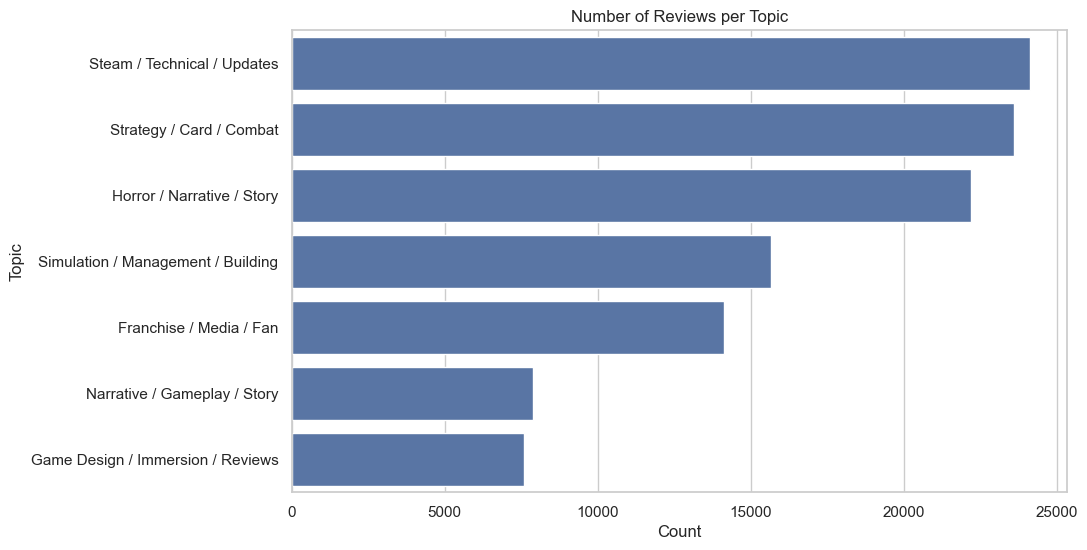

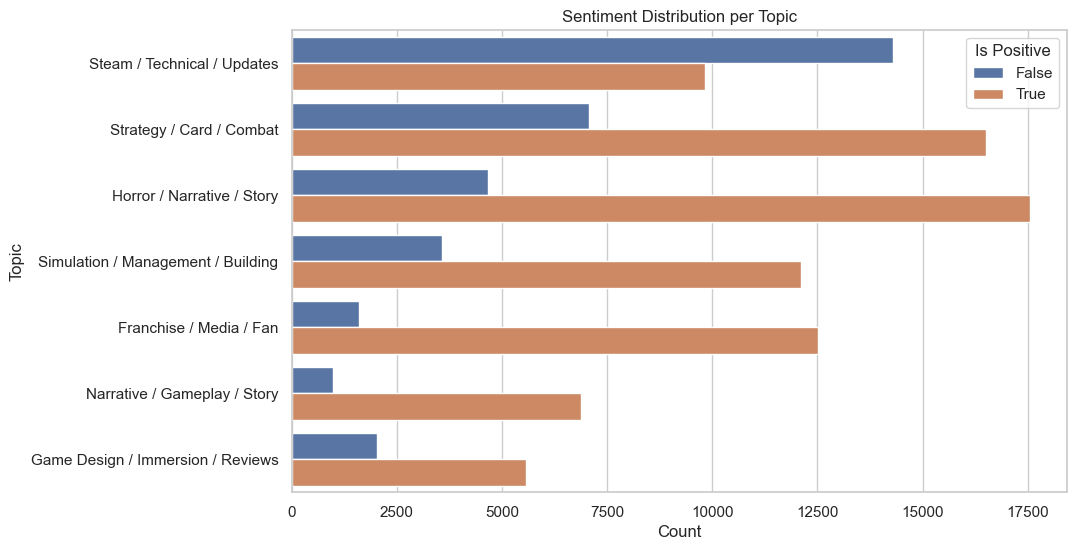

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Topic_Name', order=df['Topic_Name'].value_counts().index)
plt.title('Number of Reviews per Topic')
plt.xlabel('Count')
plt.ylabel('Topic')
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Topic_Name', hue='is_positive', 
              order=df['Topic_Name'].value_counts().index)
plt.title('Sentiment Distribution per Topic')
plt.xlabel('Count')
plt.ylabel('Topic')
plt.legend(title='Is Positive')
plt.show()
